In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import plot_tree

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [2]:
df = pd.read_csv('./data/seeds_dataset.csv')
df

,Area,Perimeter,Compactness,Length,Width,Coeff,Groove,Class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
...,...,...,...,...,...,...,...,...
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3


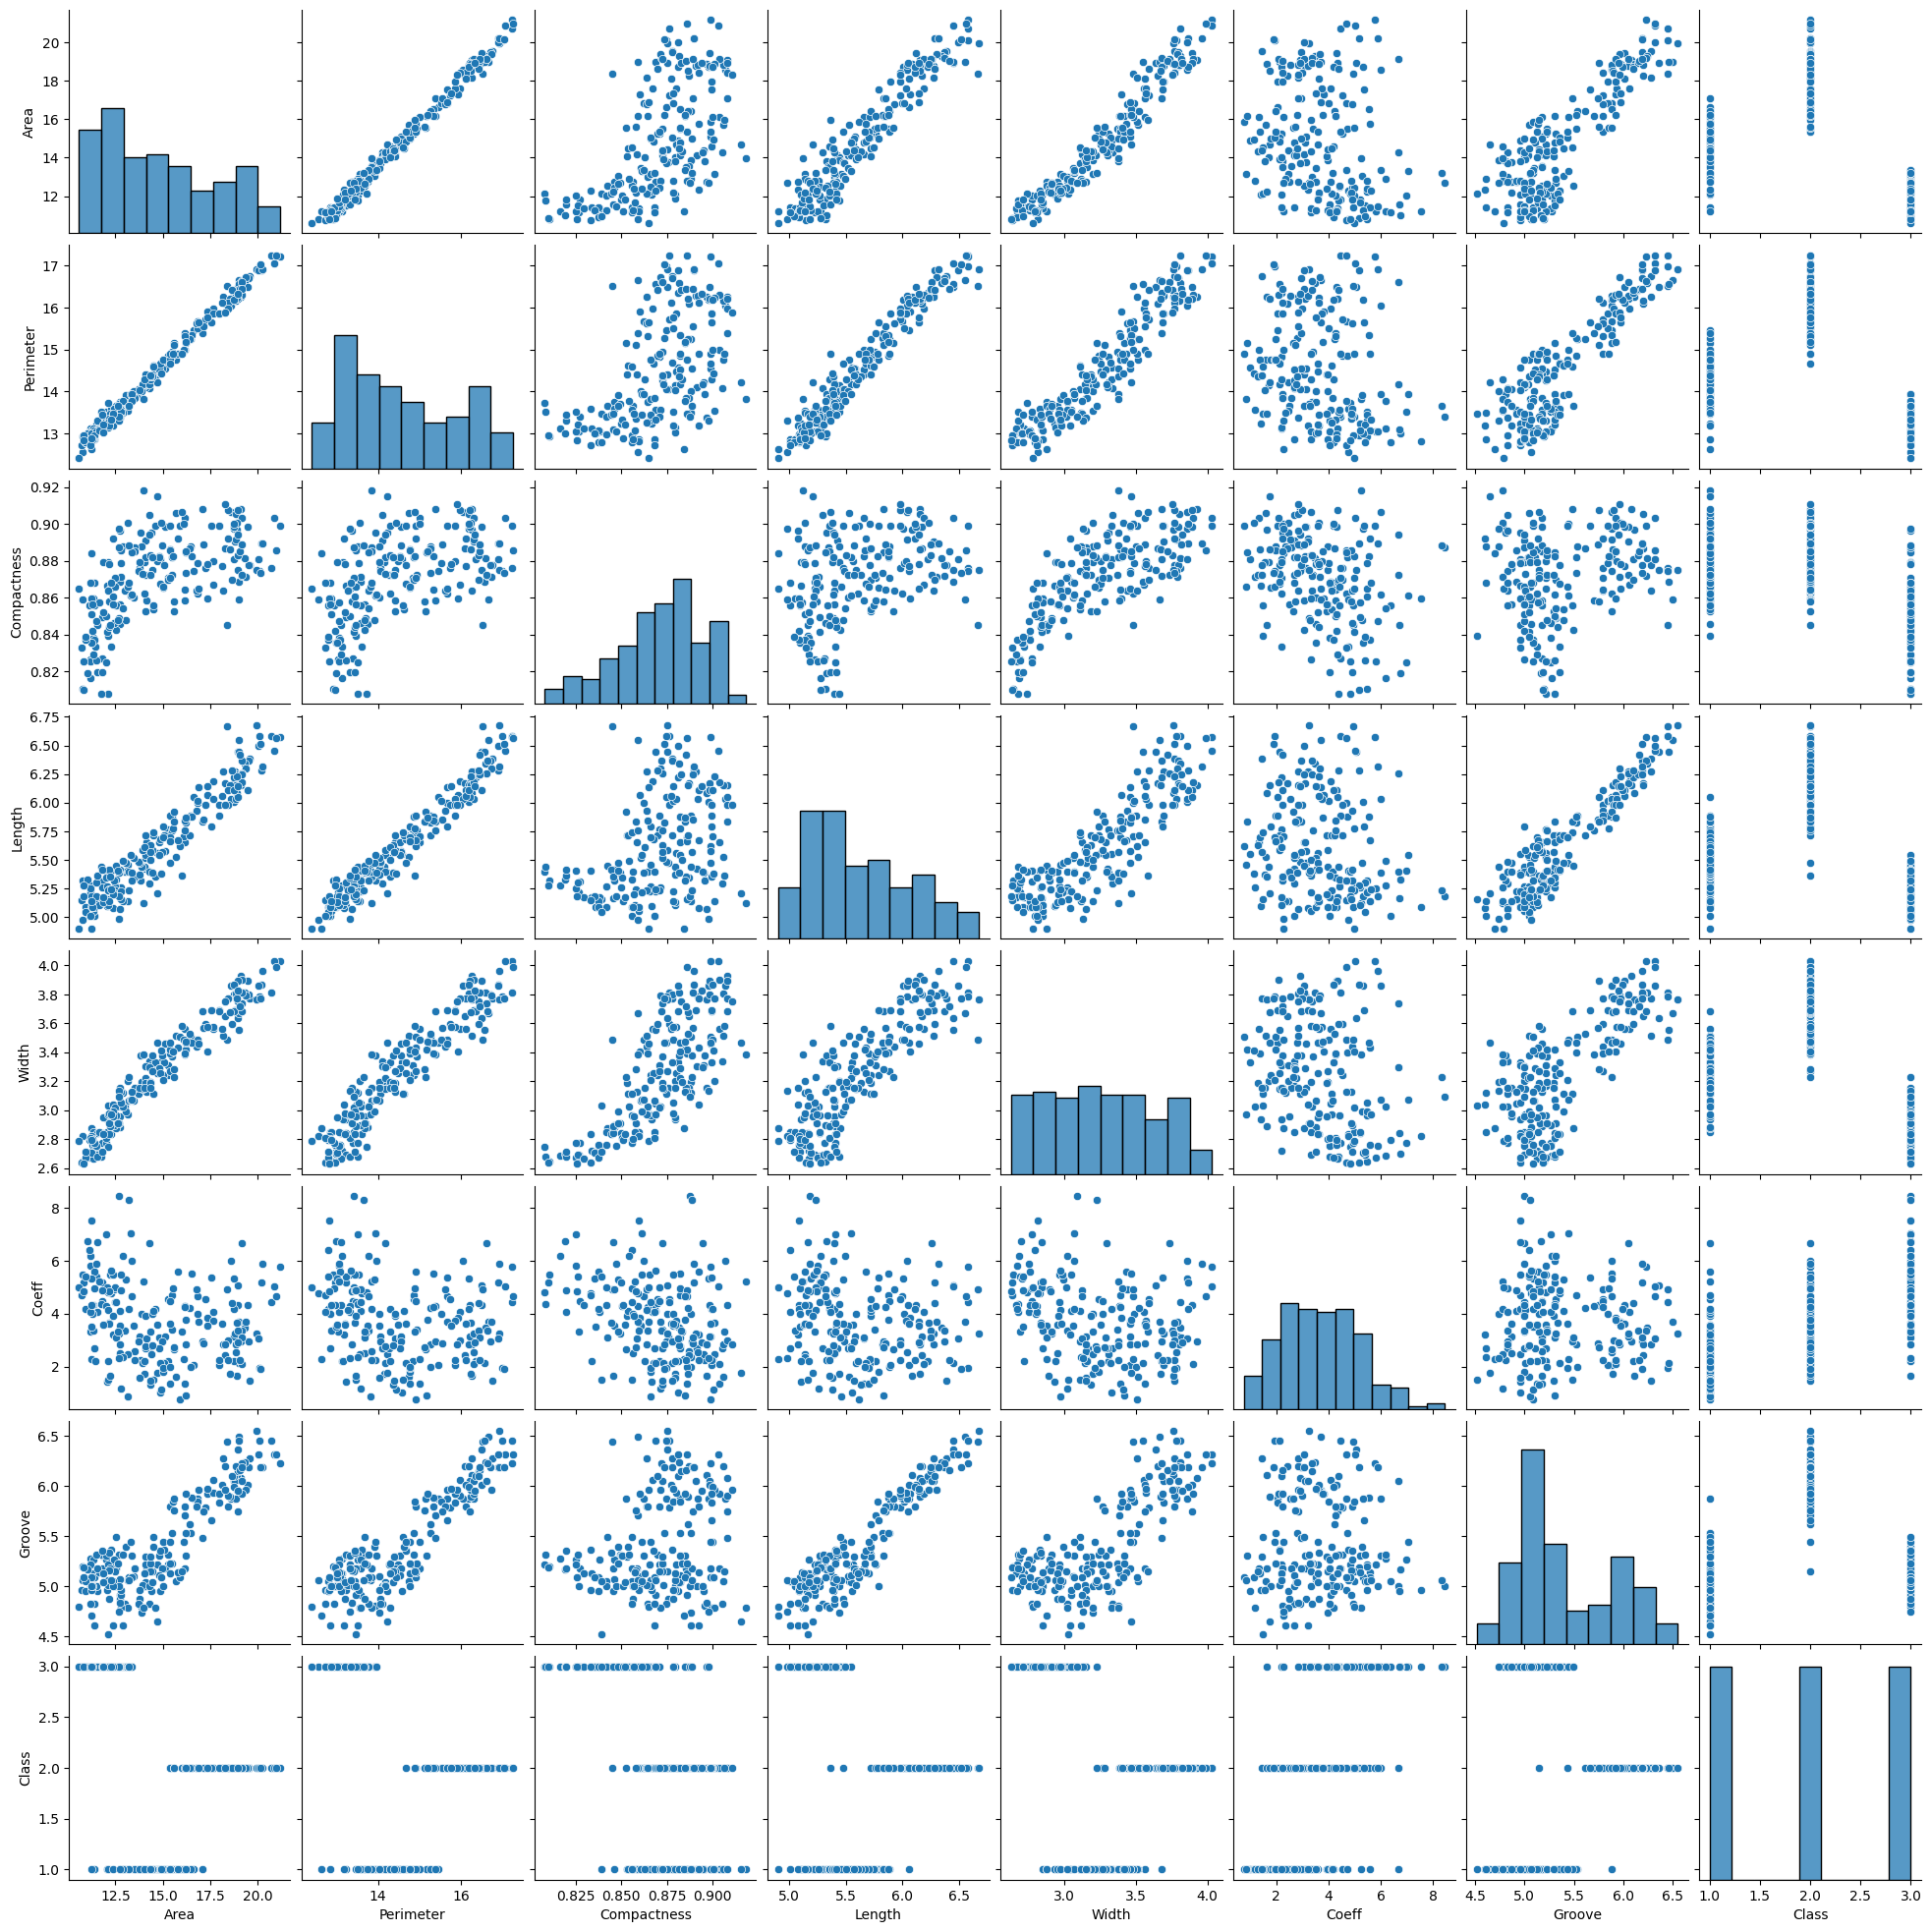

In [15]:
sns.pairplot(df)

In [3]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    
    print(f"--- {model_name} ---")
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.show()
    
    return acc

--- Logistic Regression ---
Accuracy: 0.8810

Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.64      0.78        14
           2       0.88      1.00      0.93        14
           3       0.82      1.00      0.90        14

    accuracy                           0.88        42
   macro avg       0.90      0.88      0.87        42
weighted avg       0.90      0.88      0.87        42



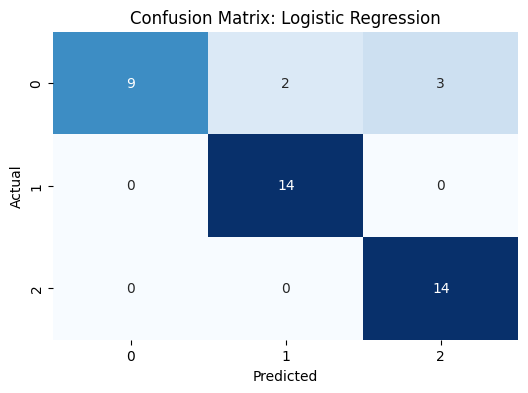

In [5]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
acc_lr = evaluate_model(lr_model, X_train_scaled, y_train, X_test_scaled, y_test, "Logistic Regression")

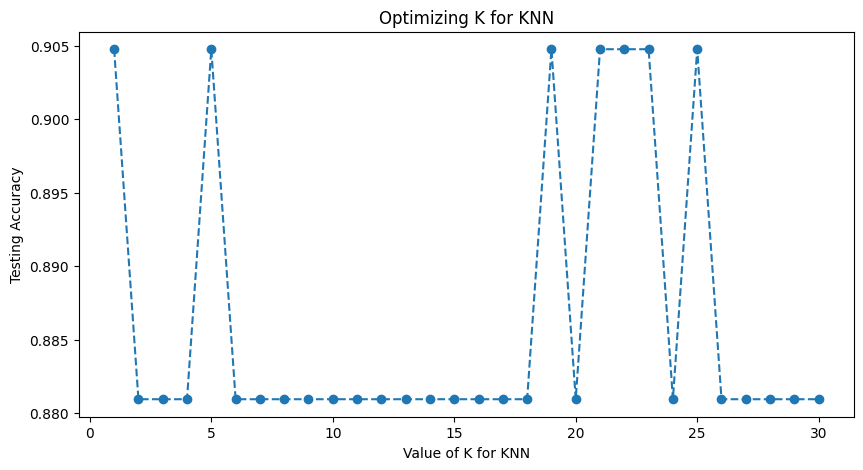

Best K value found: 1
--- KNN (k=1) ---
Accuracy: 0.9048

Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.71      0.83        14
           2       0.93      1.00      0.97        14
           3       0.82      1.00      0.90        14

    accuracy                           0.90        42
   macro avg       0.92      0.90      0.90        42
weighted avg       0.92      0.90      0.90        42



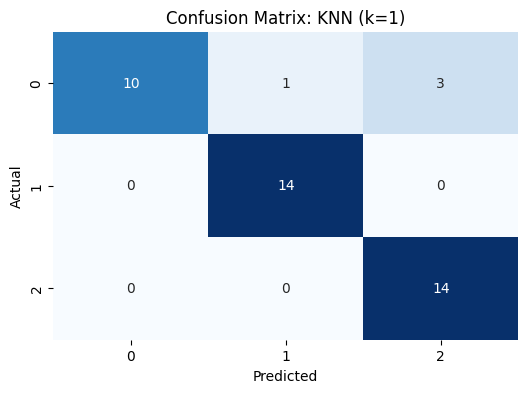

In [6]:
k_range = range(1, 31)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    scores.append(knn.score(X_test_scaled, y_test))

plt.figure(figsize=(10, 5))
plt.plot(k_range, scores, marker='o', linestyle='--')
plt.xlabel('Value of K for KNN')
plt.ylabel('Testing Accuracy')
plt.title('Optimizing K for KNN')
plt.show()

best_k = k_range[np.argmax(scores)]
print(f"Best K value found: {best_k}")

knn_best = KNeighborsClassifier(n_neighbors=best_k)
acc_knn = evaluate_model(knn_best, X_train_scaled, y_train, X_test_scaled, y_test, f"KNN (k={best_k})")

--- Decision Tree ---
Accuracy: 0.8810

Classification Report:
              precision    recall  f1-score   support

           1       0.91      0.71      0.80        14
           2       0.87      0.93      0.90        14
           3       0.88      1.00      0.93        14

    accuracy                           0.88        42
   macro avg       0.88      0.88      0.88        42
weighted avg       0.88      0.88      0.88        42



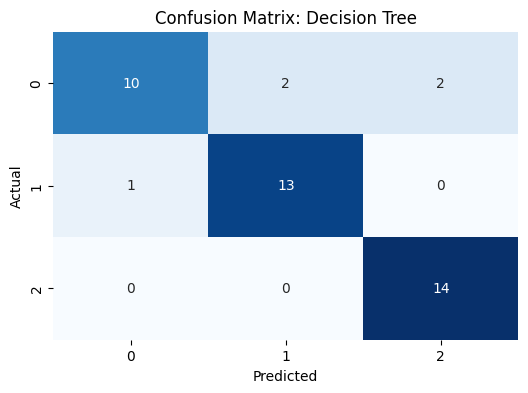

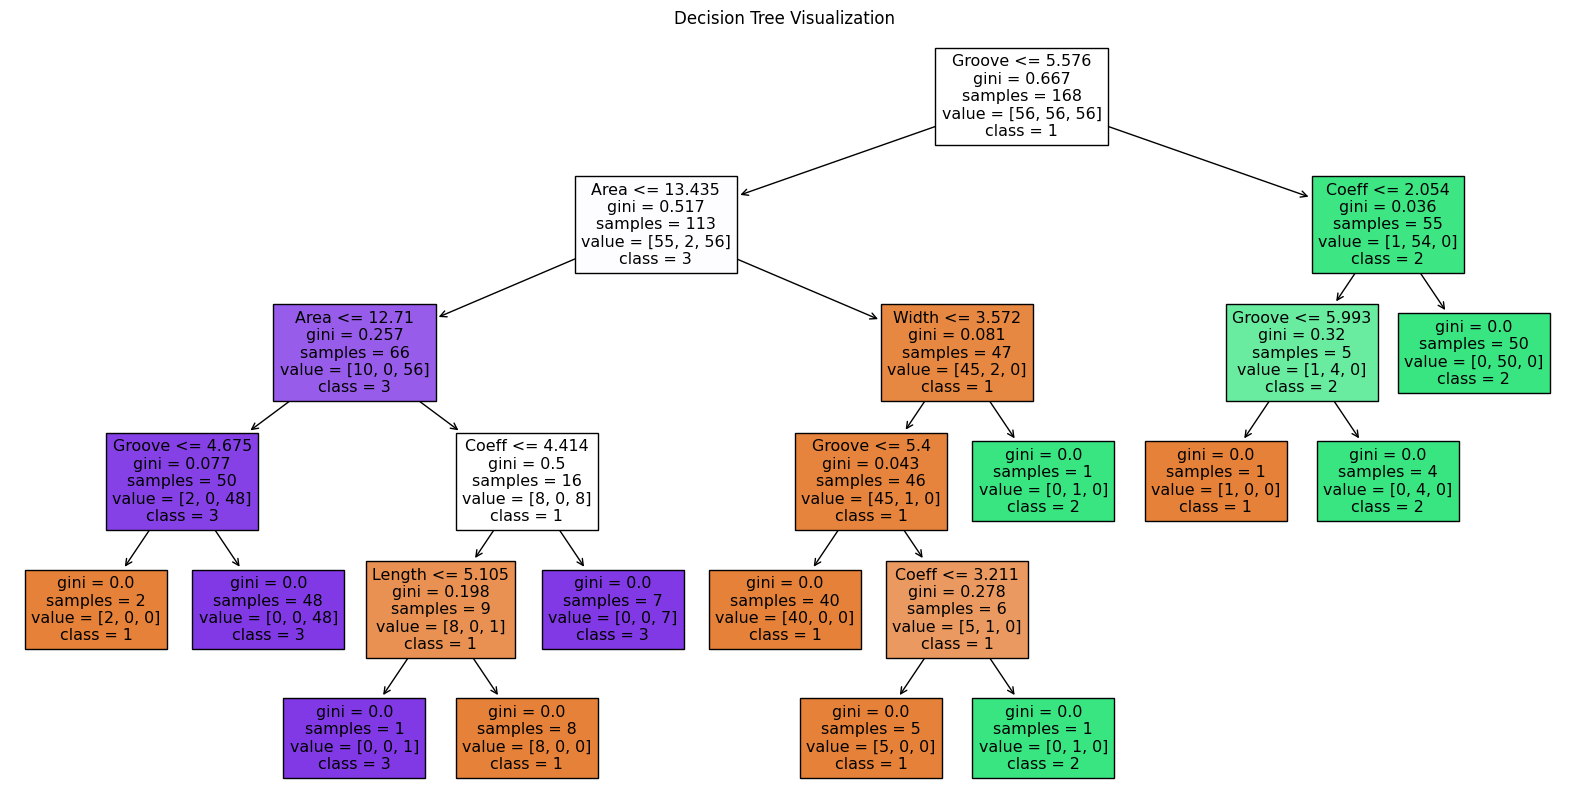

In [7]:
dt_model = DecisionTreeClassifier(random_state=42)
acc_dt = evaluate_model(dt_model, X_train, y_train, X_test, y_test, "Decision Tree")

plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=[str(c) for c in df['Class'].unique()], filled=True)
plt.title("Decision Tree Visualization")
plt.show()

--- Random Forest ---
Accuracy: 0.9048

Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.71      0.83        14
           2       0.93      1.00      0.97        14
           3       0.82      1.00      0.90        14

    accuracy                           0.90        42
   macro avg       0.92      0.90      0.90        42
weighted avg       0.92      0.90      0.90        42



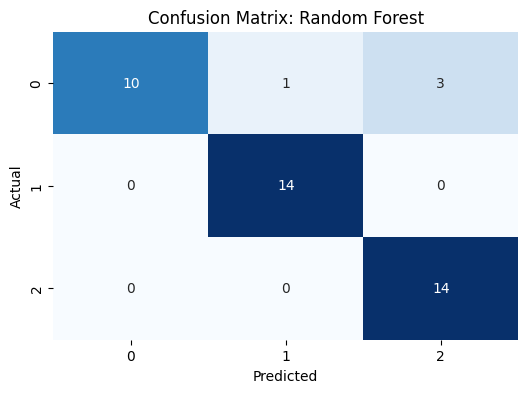

In [8]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
acc_rf = evaluate_model(rf_model, X_train, y_train, X_test, y_test, "Random Forest")

--- SVM ---
Accuracy: 0.9048

Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.71      0.83        14
           2       0.88      1.00      0.93        14
           3       0.88      1.00      0.93        14

    accuracy                           0.90        42
   macro avg       0.92      0.90      0.90        42
weighted avg       0.92      0.90      0.90        42



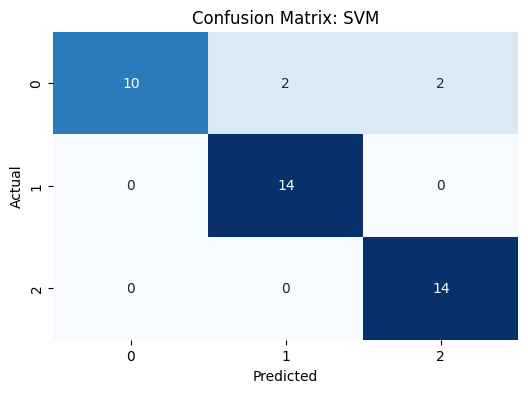

In [12]:
svm_model = SVC(kernel='rbf', random_state=42)
acc_svm = evaluate_model(svm_model, X_train_scaled, y_train, X_test_scaled, y_test, "SVM")

--- Naive Bayes ---
Accuracy: 0.8810

Classification Report:
              precision    recall  f1-score   support

           1       0.91      0.71      0.80        14
           2       0.93      0.93      0.93        14
           3       0.82      1.00      0.90        14

    accuracy                           0.88        42
   macro avg       0.89      0.88      0.88        42
weighted avg       0.89      0.88      0.88        42



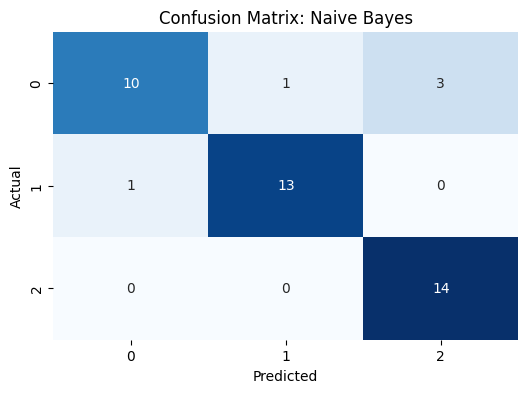

In [13]:
nb_model = GaussianNB()
acc_nb = evaluate_model(nb_model, X_train, y_train, X_test, y_test, "Naive Bayes")

                 Model  Accuracy
1                  KNN  0.904762
3        Random Forest  0.904762
4                  SVM  0.904762
0  Logistic Regression  0.880952
2        Decision Tree  0.880952
5          Naive Bayes  0.880952


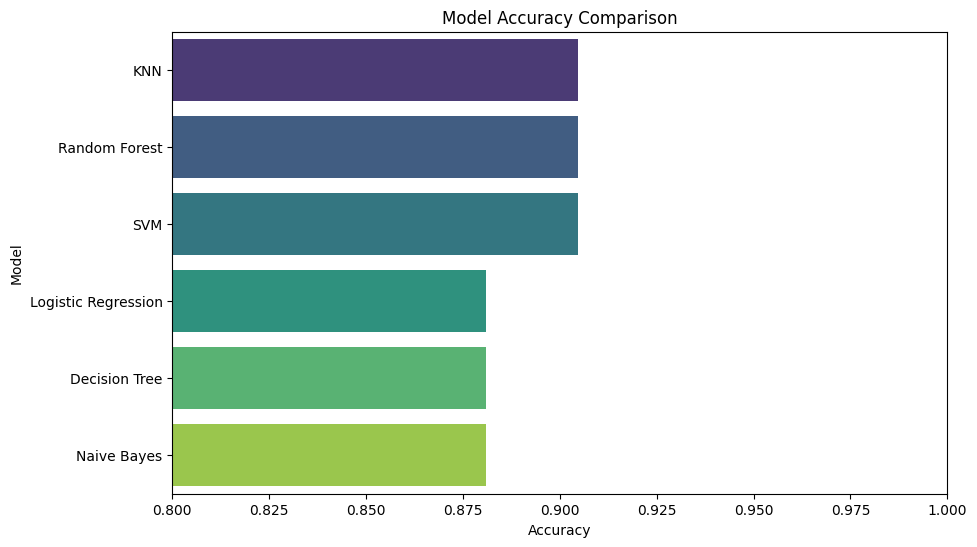

In [14]:
models_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'SVM', 'Naive Bayes'],
    'Accuracy': [acc_lr, acc_knn, acc_dt, acc_rf, acc_svm, acc_nb]
})

print(models_summary.sort_values(by='Accuracy', ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=models_summary.sort_values(by='Accuracy', ascending=False), palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlim(0.8, 1.0)
plt.show()

# What model is best for this dataset?

The Support Vector Machine (SVM) is the recommended classifier for this problem

It achieved the highest joint accuracy (90.48%), tied with Random Forest and KNN but unlike KNN (k=1), which can be overly sensitive to noise and outliers (overfitting), SVM generalizes better on small-to-medium datasets like this one (210 observations)

While Random Forest also performed well, SVMs are often computationally more efficient and mathematically robust for datasets of this size where feature margins are critical for separating overlapping classes (specifically Class 1)

If interpretability is the absolute priority, the Decision Tree (88.1%) is a viable alternative, but for pure predictive power, SVM is the superior choice.